In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MultiLabelBinarizer,  StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
tqdm.pandas(desc="Processing Rows")
import os

import gc
import time
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
import ast
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    r2_score
)
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
import seaborn as sns
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
hf_token = "os.environ['HF_TOKEN']" 

/apps/common/software/Miniforge3/25.11.0-1-jupyter-base/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
model_id = "meta-llama/Llama-2-13b-hf"
from transformers import AutoTokenizer, AutoModelForCausalLM

hf_token = "os.environ['HF_TOKEN']" 

tokenizer = AutoTokenizer.from_pretrained(model_id,token=hf_token)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=hf_token
)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 363/363 [00:48<00:00,  7.53it/s]


In [2]:

df=pd.read_csv("../Datasets/World_Ecological_2015_Metadata.csv")

columns = [
    'geonameid', 'name', 'asciiname', 'alternatenames', 
    'latitude', 'longitude', 'feature_class', 'feature_code', 
    'country_code', 'cc2', 'admin1', 'admin2', 'admin3', 'admin4', 
    'population', 'elevation', 'dem', 'timezone', 'modification_date'
]

df_geo = pd.read_csv('../Datasets/allCountries.txt', sep='\t', names=columns, low_memory=False)
df_landforms = df_geo[df_geo['feature_class'] == 'T']
combined_dataset=pd.read_csv("../Datasets/Global_Named_Landforms_With_Labels.csv")
combined_dataset=combined_dataset[['name','alternatenames','feature_code','ELU_LF_Des']]
exact_6_class_map = {
    # 1: Plains
    'PLN': 1, 'PLNS': 1, 'FLT': 1, 'PANS': 1,
    
    # 2: Hills and Low Tablelands
    'HLL': 2, 'HLLS': 2, 'MND': 2, 'KNOB': 2,
    
    # 3: High Tablelands
    'PT': 3, 'PLAT': 3, 'MESA': 3, 'BUTT': 3,
    
    # 4: Ridges
    'RDG': 4, 'RDGS': 4, 'SADL': 4, 'DUNE': 4,
    
    # 5: Widely Spaced Mountains
    'MT': 5, 'MTS': 5, 'PK': 5, 'PKS': 5, 'CONE': 5, 'VOLC': 5, 'NUP': 5, 'RK': 5,
    
    # 7: Depressions or Basins
    'BSN': 7, 'BSNS': 7, 'DPR': 7, 'SINK': 7, 'CRQS': 7, 'CRATER': 7
}

combined_dataset['macro_class_id'] = combined_dataset['feature_code'].map(exact_6_class_map)
combined_dataset = combined_dataset.dropna(subset=['macro_class_id'])
combined_dataset['macro_class_id'] = combined_dataset['macro_class_id'].astype(int)
combined_dataset=combined_dataset[~combined_dataset['macro_class_id'].isna()]
combined_dataset=combined_dataset[['name','macro_class_id']]
combined_dataset.columns=['Bridges Full Name','Topographic']
combined_dataset = combined_dataset.groupby('Bridges Full Name')['Topographic'].apply(lambda x: list(set(x))).reset_index()
ascii_mask = combined_dataset['Bridges Full Name'].astype(str).str.contains(r'^[\x00-\x7F]+$')
combined_dataset = combined_dataset[ascii_mask].reset_index(drop=True)
combined_dataset

/localscratch/6424016/ipykernel_3495345/1853054812.py:12: DtypeWarning: Columns (9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_dataset=pd.read_csv("../Datasets/Global_Named_Landforms_With_Labels.csv")


,Bridges Full Name,Topographic
0,'Adade Yus Mountain,[5]
1,'Aqabat Nikid,[5]
2,'Elb Chouf,[4]
3,'Elb ech Chaoufa,[4]
4,'S Airde Beinn,[2]
...,...,...
618599,wzgorze na Katarynkach,[2]
618600,wzgorze nad Tuchlinkiem,[2]
618601,yak Gawa,[5]
618602,ytre Midtberget,[2]


In [ ]:
combined_dataset.iloc[1000:1040]

In [3]:
def label_to_list(x):
    if isinstance(x, np.ndarray):
        return [int(v) for v in x.tolist()]

    if isinstance(x, (list, tuple)):
        return [int(v) for v in x]

    if isinstance(x, str):
        x = x.strip()
        if x.startswith("["):
            return [int(v) for v in ast.literal_eval(x)]
        return [int(float(x))]

    return [int(x)]


X = combined_dataset["Bridges Full Name"].astype(str)
y_labels = combined_dataset["Topographic"].apply(label_to_list)

# optional: stratify by exact label-combination string
y_combo = y_labels.apply(lambda z: tuple(sorted(z)))

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X,
    y_labels,
    test_size=0.20,
    stratify=None,
    random_state=42
)
MAX_TRAIN = 100000
MAX_TEST = 20000

train_combo = y_train_full.apply(lambda z: tuple(sorted(z)))
test_combo = y_test_full.apply(lambda z: tuple(sorted(z)))

X_train_list, _, y_train_labels, _ = train_test_split(
    X_train_full.tolist(),
    y_train_full.tolist(),
    train_size=min(MAX_TRAIN, len(X_train_full)),
    stratify=None,
    random_state=42
)

X_test_list, _, y_test_labels, _ = train_test_split(
    X_test_full.tolist(),
    y_test_full.tolist(),
    train_size=min(MAX_TEST, len(X_test_full)),
    stratify=None,
    random_state=42
)

mlb = MultiLabelBinarizer()
Y_train = mlb.fit_transform(y_train_labels)
Y_test = mlb.transform(y_test_labels)

print("Classes:", mlb.classes_)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)


In [6]:
# import pickle

# with open("train_cache.pkl", "wb") as f:
#     pickle.dump(train_cache, f)

# with open("test_cache.pkl", "wb") as f:
#     pickle.dump(test_cache, f)
# with open("labels.pkl", "wb") as f:
#     pickle.dump({
#         "Y_train": Y_train,
#         "Y_test": Y_test
#     }, f)

In [7]:
# import pickle

# with open("train_cache.pkl", "rb") as f:
#     train_cache = pickle.load(f)

# with open("test_cache.pkl", "rb") as f:
#     test_cache = pickle.load(f)

# with open("labels.pkl", "rb") as f:
#     labels = pickle.load(f)

# Y_train = labels["Y_train"]
# Y_test = labels["Y_test"]

In [ ]:
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
torch.set_num_threads(8)
torch.cuda.empty_cache()
BATCH_SIZE = 128
MAX_LEN = 64
num_blocks = len(model.model.layers)
# num_blocks = len(model.gpt_neox.layers)
print("Transformer blocks:", num_blocks)
HIDDEN_STATE_LAYERS = [36]


if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model.eval()
model.config.use_cache = False

if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()

train_loader = DataLoader(
    X_train_list,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    X_test_list,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
# first extract layers
def extract_selected_token_states(loader, desc, hidden_state_layers):
    chunks = {l: [] for l in hidden_state_layers}

    with torch.inference_mode():
        for batch in tqdm(loader, desc=desc):
            inputs = tokenizer(
                list(batch),
                padding=True,
                truncation=True,
                max_length=MAX_LEN,
                return_tensors="pt"
            ).to(model.device)
            lengths = inputs["attention_mask"].sum(dim=1) - 1
            batch_idx = torch.arange(inputs["input_ids"].shape[0], device=model.device)

            with torch.inference_mode():
                outputs = model(
                    **inputs,
                    output_hidden_states=True,
                    use_cache=False
                )

            for l in hidden_state_layers:
                hs = outputs.hidden_states[l]
                tok_state = hs[batch_idx, lengths, :]
                chunks[l].append(tok_state.float().cpu().numpy().astype(np.float32))

            del inputs, outputs, lengths, batch_idx, tok_state
            gc.collect()

    return {l: np.vstack(chunks[l]) for l in hidden_state_layers}

start = time.perf_counter()

print("\nExtracting train hidden states...")
train_cache = extract_selected_token_states(train_loader, "Train", HIDDEN_STATE_LAYERS)

print("\nExtracting test hidden states...")
test_cache = extract_selected_token_states(test_loader, "Test", HIDDEN_STATE_LAYERS)

print(f"\nExtraction time: {(time.perf_counter() - start) / 60:.2f} min")

np.save("train_layer36.npy", train_cache[36])
np.save("test_layer36.npy", test_cache[36])

Transformer blocks: 40

Extracting train hidden states...


Train:   0%|          | 0/782 [00:00<?, ?it/s]

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel,
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)

REP_LAYER = 36
COMPONENTS = 32
N = 5000
RANDOM_STATE = 42

Xtr = np.asarray(train_cache[REP_LAYER])
Xte = np.asarray(test_cache[REP_LAYER])

rng = np.random.default_rng(RANDOM_STATE)

train_idx = rng.choice(
    len(Xtr),
    size=min(N, len(Xtr)),
    replace=False,
)

test_idx = rng.choice(
    len(Xte),
    size=min(N, len(Xte)),
    replace=False,
)

Xtr_small = Xtr[train_idx]
Ytr_small = np.asarray(Y_train)[train_idx]

Xte_small = Xte[test_idx]
Yte_small = np.asarray(Y_test)[test_idx]

# Learn PCA only from training data.
pca = PCA(
    n_components=COMPONENTS,
    random_state=RANDOM_STATE,
)

Xtr_pca = pca.fit_transform(Xtr_small)
Xte_pca = pca.transform(Xte_small)

# Put PCA components on comparable scales.
scaler = StandardScaler()
Xtr_gp = scaler.fit_transform(Xtr_pca)
Xte_gp = scaler.transform(Xte_pca)

gps = {}
gp_results = []

for col_idx, raw_label in enumerate(mlb.classes_):
    print(f"\nTraining GP for {raw_label}")

    ytr = Ytr_small[:, col_idx].astype(float)
    yte = Yte_small[:, col_idx].astype(int)

    if np.unique(ytr).size < 2:
        print("Skipped: the training subset does not contain both classes.")
        continue

    kernel = (
        ConstantKernel(1.0, (1e-2, 1e2))
        * RBF(1.0, (1e-2, 1e2))
        + WhiteKernel(0.1, (1e-5, 1e1))
    )

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        alpha=1e-6,
        random_state=RANDOM_STATE,
    )

    gpr.fit(Xtr_gp, ytr)

    score, uncertainty = gpr.predict(
        Xte_gp,
        return_std=True,
    )

    prediction = (score >= 0.5).astype(int)
    correct = prediction == yte

    result = {
        "raw_label": raw_label,
        "column": col_idx,
        "positive_count": int(yte.sum()),
        "positive_rate": float(yte.mean()),
        "accuracy": accuracy_score(yte, prediction),
        "f1": f1_score(yte, prediction, zero_division=0),
        "precision": precision_score(
            yte, prediction, zero_division=0
        ),
        "recall": recall_score(
            yte, prediction, zero_division=0
        ),
        "score_mean": float(score.mean()),
        "uncertainty_mean": float(uncertainty.mean()),
        "uncertainty_correct": (
            float(uncertainty[correct].mean())
            if correct.any()
            else np.nan
        ),
        "uncertainty_incorrect": (
            float(uncertainty[~correct].mean())
            if (~correct).any()
            else np.nan
        ),
    }

    # These metrics require both classes in the test subset.
    if np.unique(yte).size == 2:
        result["roc_auc"] = roc_auc_score(yte, score)
        result["average_precision"] = average_precision_score(
            yte, score
        )
    else:
        result["roc_auc"] = np.nan
        result["average_precision"] = np.nan

    gps[raw_label] = gpr
    gp_results.append(result)

    print("Learned kernel:", gpr.kernel_)
    print("F1:", result["f1"])
    print("Average precision:", result["average_precision"])
    print(
        "Average uncertainty on incorrect predictions:",
        result["uncertainty_incorrect"],
    )

gp_results_df = pd.DataFrame(gp_results)

best_layer = REP_LAYER
best_pca = pca
best_scaler = scaler
best_gps = gps

In [ ]:
def gp_objective(gp, z, uncertainty_weight=0.5):
    mean, std = gp.predict(z[None], return_std=True)
    return mean[0] - uncertainty_weight * std[0]


def gp_gradient(
    gp,
    z,
    delta=0.01,
    uncertainty_weight=0.5
):
    grad = np.zeros_like(z, dtype=float)

    for j in range(len(z)):
        z_plus = z.copy()
        z_minus = z.copy()

        z_plus[j] += delta
        z_minus[j] -= delta

        score_plus = gp_objective(
            gp,
            z_plus,
            uncertainty_weight
        )

        score_minus = gp_objective(
            gp,
            z_minus,
            uncertainty_weight
        )

        grad[j] = (score_plus - score_minus) / (2 * delta)

    return grad


def follow_gp_gradient(
    gp,
    z0,
    total_distance,
    step_size=0.1,
    delta=0.01,
    uncertainty_weight=0.5
):
    z = z0.copy()
    distance_moved = 0.0

    while distance_moved < total_distance:
        gradient = gp_gradient(
            gp,
            z,
            delta=delta,
            uncertainty_weight=uncertainty_weight
        )

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm < 1e-8:
            break

        direction = gradient / gradient_norm

        current_step = min(
            step_size,
            total_distance - distance_moved
        )

        z = z + current_step * direction
        distance_moved += current_step

    return z

In [ ]:
X = test_cache[best_layer]
if torch.is_tensor(X): 
    X = X.detach().cpu().numpy()

l = []
Z = best_scaler.transform(best_pca.transform(X))
df = dict()
cols = []

for label, gp in best_gps.items():
    df[f"Label {label}"] = dict()
    
    for i in [0, 10, 15, 25, 100, 150, 200]:
        z0 = Z[i]
        df[f"Label {label}"][str(i)] = dict()

        m0, s0 = gp.predict(z0[None], return_std=True)

        x0 = best_pca.inverse_transform(
            best_scaler.inverse_transform(z0[None])
        )[0]

        for alpha in [
            0.1, 0.5, 0.75, 1,
         1.5,  2,
             2.5, 3, 4
        ]:
            df[f"Label {label}"][str(i)][str(alpha)] = []

            z = follow_gp_gradient(
                gp=gp,
                z0=z0,
                total_distance=alpha,
                step_size=0.1,
                delta=0.01,
                uncertainty_weight=0.5
            )

            m, s = gp.predict(z[None], return_std=True)

            x = best_pca.inverse_transform(
                best_scaler.inverse_transform(z[None])
            )[0]

            rel = np.linalg.norm(x - x0) / (
                np.linalg.norm(x0) + 1e-8
            )

            df[f"Label {label}"][str(i)][str(alpha)].append(m[0])
            df[f"Label {label}"][str(i)][str(alpha)].append(s[0])
            df[f"Label {label}"][str(i)][str(alpha)].append(rel)
            print(f"alpha {alpha} done")
        print(i)
    print(label)

In [20]:
rows = []

for label, index_data in df.items():
    for index, alpha_data in index_data.items():
        for alpha, values in alpha_data.items():
            rows.append({
                "label": label,
                "index": int(index),
                "alpha": float(alpha),
                "mean": values[0],
                "std": values[1],
                "rel_norm": values[2],
            })

plot_df = pd.DataFrame(rows)

In [21]:
plot_df.to_csv("alpha_sweep_llama.csv",index=False)

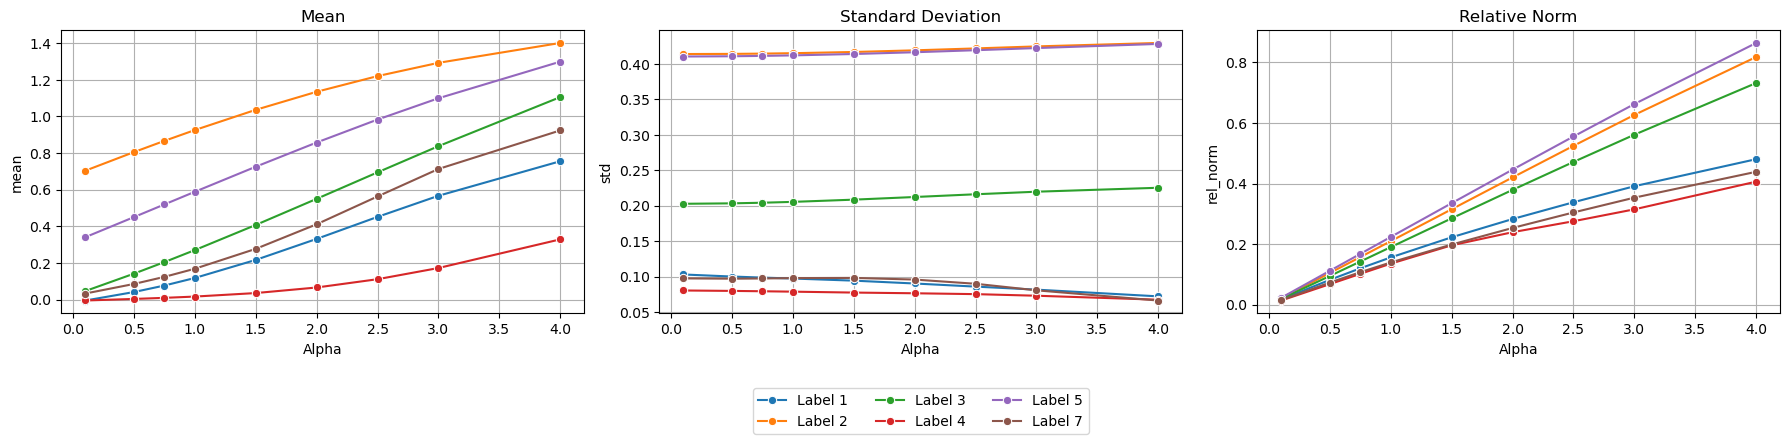

In [35]:
summary = (
    plot_df.groupby(["label", "alpha"], as_index=False)
           .agg(mean=("mean", "mean"),
                std=("std", "mean"),
                rel_norm=("rel_norm", "mean"))
)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(
    axes,
    ["mean", "std", "rel_norm"],
    ["Mean", "Standard Deviation", "Relative Norm"]
):
    sns.lineplot(
        data=summary,
        x="alpha",
        y=metric,
        hue="label",
        marker="o",
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Alpha")
    ax.grid(True)

axes[0].legend_.remove()
axes[2].legend_.remove()
axes[1].legend(loc="lower center", bbox_to_anchor=(0.5, -0.45), ncols=3)
# plt

plt.tight_layout()
plt.show()

In [23]:
BETA = 0.5

summary["utility"] = (
    summary["mean"] - BETA * summary["std"]
)

alpha_scores = (
    summary.groupby("alpha", as_index=False)
    .agg(utility=("utility", "mean"))
)

best_alpha = float(
    alpha_scores.loc[
        alpha_scores["utility"].idxmax(),
        "alpha"
    ]
)

print("Frozen alpha:", best_alpha)

Frozen alpha: 4.0


In [45]:
def gp_gradient(
    gp,
    z,
    delta=0.01,
    uncertainty_weight=0.5,
):
    n_dims = len(z)

    offsets = np.eye(n_dims) * delta

    Z_plus = z[None, :] + offsets
    Z_minus = z[None, :] - offsets

    mean_plus, std_plus = gp.predict(
        Z_plus,
        return_std=True,
    )

    mean_minus, std_minus = gp.predict(
        Z_minus,
        return_std=True,
    )

    score_plus = (
        mean_plus - uncertainty_weight * std_plus
    )

    score_minus = (
        mean_minus - uncertainty_weight * std_minus
    )

    return (score_plus - score_minus) / (2 * delta)


def follow_gp_gradient(
    gp,
    z0,
    total_distance,
    step_size=0.5,
    delta=0.01,
    uncertainty_weight=0.5,
):
    z = np.asarray(z0, dtype=float).copy()

    n_steps = int(np.ceil(total_distance / step_size))

    for step in range(n_steps):
        gradient = gp_gradient(
            gp=gp,
            z=z,
            delta=delta,
            uncertainty_weight=uncertainty_weight,
        )

        gradient_norm = np.linalg.norm(gradient)

        if gradient_norm < 1e-8:
            break

        remaining_distance = (
            total_distance - step * step_size
        )

        current_step = min(
            step_size,
            remaining_distance,
        )

        z += current_step * (
            gradient / gradient_norm
        )

    return z

In [46]:
import joblib
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

probe = joblib.load(
    "../Probes/llama13b-probes/best_linear_probe.pkl"
)

N_EVAL = 1000
N_JOBS = 8
STEP_SIZE = 0.5

class_to_col = {
    label: i for i, label in enumerate(mlb.classes_)
}

results = []

for target_label, gp in best_gps.items():
    print(f"\nStarting: {target_label}")

    col = class_to_col[target_label]
    mask = Yte_small[:, col] == 0
    X_eval = Xte_small[mask][:N_EVAL]

    if len(X_eval) == 0:
        print("No evaluation samples")
        continue

    before = probe.predict_proba(X_eval)[:, col]

    Z_eval = best_scaler.transform(
        best_pca.transform(X_eval)
    )

    print(f"Steering {len(Z_eval)} samples...")

    Z_steered = Parallel(
        n_jobs=N_JOBS,
        prefer="threads",
        verbose=10,
    )(
        delayed(follow_gp_gradient)(
            gp=gp,
            z0=z0,
            total_distance=best_alpha,
            step_size=STEP_SIZE,
            delta=0.01,
            uncertainty_weight=BETA,
        )
        for z0 in Z_eval
    )

    Z_steered = np.asarray(Z_steered)

    X_steered = best_pca.inverse_transform(
        best_scaler.inverse_transform(Z_steered)
    )

    after = probe.predict_proba(X_steered)[:, col]
    change = after - before

    results.append({
        "label": target_label,
        "n_samples": len(X_eval),
        "mean_probability_before": before.mean(),
        "mean_probability_after": after.mean(),
        "mean_change": change.mean(),
        "fraction_increased": (change > 0).mean(),
    })

    print(f"Finished: {target_label}")

results_df = pd.DataFrame(results)
print(results_df)


Starting: 1
Steering 1000 samples...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    9.1s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:   18.2s
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:   25.4s
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:   39.4s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:   51.9s
[Parallel(n_jobs=8)]: Done  45 tasks      | elapsed:  1.2min
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:  1.4min
[Parallel(n_jobs=8)]: Done  69 tasks      | elapsed:  1.7min
[Parallel(n_jobs=8)]: Done  82 tasks      | elapsed:  2.0min
[Parallel(n_jobs=8)]: Done  97 tasks      | elapsed:  2.3min
[Parallel(n_jobs=8)]: Done 112 tasks      | elapsed:  2.6min
[Parallel(n_jobs=8)]: Done 129 tasks      | elapsed:  3.0min
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:  3.4min
[Parallel(n_jobs=8)]: Done 165 tasks      | elapsed:  3.8min
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:  4.2min
[Para

Finished: 1

Starting: 2
Steering 1000 samples...


[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    7.6s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:   14.2s
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:   19.2s
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:   29.8s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:   38.1s
[Parallel(n_jobs=8)]: Done  45 tasks      | elapsed:   46.9s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:   60.0s
[Parallel(n_jobs=8)]: Done  69 tasks      | elapsed:  1.2min
[Parallel(n_jobs=8)]: Done  82 tasks      | elapsed:  1.4min
[Parallel(n_jobs=8)]: Done  97 tasks      | elapsed:  1.6min
[Parallel(n_jobs=8)]: Done 112 tasks      | elapsed:  1.9min
[Parallel(n_jobs=8)]: Done 129 tasks      | elapsed:  2.3min
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:  2.5min
[Parallel(n_jobs=8)]: Done 165 tasks      | elapsed:  2.9min
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:  3.2min
[Parallel(n_jobs=8)]: Done 205 tasks      | elapsed:  3.5min
[Parallel(n_jobs=8)]: Do

Finished: 2

Starting: 3
Steering 1000 samples...


...

[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:   10.3s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:   15.5s
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:   21.9s
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:   30.6s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:   40.7s
[Parallel(n_jobs=8)]: Done  45 tasks      | elapsed:   51.5s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:  1.0min
[Parallel(n_jobs=8)]: Done  69 tasks      | elapsed:  1.3min
[Parallel(n_jobs=8)]: Done  82 tasks      | elapsed:  1.5min
[Parallel(n_jobs=8)]: Done  97 tasks      | elapsed:  1.7min
[Parallel(n_jobs=8)]: Done 112 tasks      | elapsed:  2.0min
[Parallel(n_jobs=8)]: Done 129 tasks      | elapsed:  2.3min
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:  2.6min
[Parallel(n_jobs=8)]: Done 165 tasks      | elapsed:  3.0min
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:  3.3min
[Parallel(n_jobs=8)]: Done 205 tasks      | elapsed:  3.7min
[Parallel(n_jobs=8)]: Do

Finished: 5

Starting: 7
Steering 1000 samples...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    8.9s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:   15.2s
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:   19.3s
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:   30.3s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:   37.8s
[Parallel(n_jobs=8)]: Done  45 tasks      | elapsed:   50.0s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:   58.8s
[Parallel(n_jobs=8)]: Done  69 tasks      | elapsed:  1.2min
[Parallel(n_jobs=8)]: Done  82 tasks      | elapsed:  1.4min
[Parallel(n_jobs=8)]: Done  97 tasks      | elapsed:  1.7min
[Parallel(n_jobs=8)]: Done 112 tasks      | elapsed:  1.9min
[Parallel(n_jobs=8)]: Done 129 tasks      | elapsed:  2.1min
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:  2.4min
[Parallel(n_jobs=8)]: Done 165 tasks      | elapsed:  2.6min
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:  2.9min
[Para

Finished: 7
   label  n_samples  mean_probability_before  mean_probability_after  \
0      1       1000                 0.006000                0.063518   
1      2       1000                 0.282385                0.942306   
2      3       1000                 0.021419                0.816058   
3      4       1000                 0.004000                0.054053   
4      5       1000                 0.293653                0.927752   
5      7       1000                 0.002000                0.014000   

   mean_change  fraction_increased  
0     0.057518               0.153  
1     0.659921               0.995  
2     0.794639               0.825  
3     0.050053               0.152  
4     0.634099               0.997  
5     0.012000               0.123  


[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed: 15.3min finished


In [47]:
results_df.to_csv("res.csv",index=False)

In [52]:
results_df=pd.read_csv("res.csv")

In [50]:
for label, gp in best_gps.items():
    print(label, gp.kernel_)

1 1.01**2 * RBF(length_scale=1.98) + WhiteKernel(noise_level=1.08e-05)
2 0.597**2 * RBF(length_scale=4.3) + WhiteKernel(noise_level=0.648)
3 0.732**2 * RBF(length_scale=3.78) + WhiteKernel(noise_level=0.312)
4 0.904**2 * RBF(length_scale=1.34) + WhiteKernel(noise_level=0.0845)
5 0.637**2 * RBF(length_scale=4.57) + WhiteKernel(noise_level=0.622)
7 1.04**2 * RBF(length_scale=1.59) + WhiteKernel(noise_level=1e-05)


In [53]:
for row in results:
    gp = best_gps[row["label"]]
    kernel = gp.kernel_

    row["length_scale"] = kernel.k1.k2.length_scale
    row["signal_variance"] = kernel.k1.k1.constant_value
    row["noise_level"] = kernel.k2.noise_level

results_df2 = pd.DataFrame(results)

print(
    results_df2[
        [
            "label",
            "mean_change",
            "fraction_increased",
            "length_scale",
            "noise_level",
        ]
    ]
)

KeyError: "None of [Index(['label', 'mean_change', 'fraction_increased', 'length_scale',\n       'noise_level'],\n      dtype='object')] are in the [columns]"

In [54]:
training_counts = Ytr_small.sum(axis=0)

for label in best_gps:
    col = class_to_col[label]

    print(
        label,
        "training positives:",
        int(training_counts[col])
    )

1 training positives: 122
2 training positives: 2077
3 training positives: 594
4 training positives: 43
5 training positives: 2339
7 training positives: 67


In [55]:
results_df["training_positives"] = results_df["label"].map({
    1: 122,
    2: 2077,
    3: 594,
    4: 43,
    5: 2339,
    7: 67,
})

print(
    results_df[
        [
            "training_positives",
            "mean_change",
            "fraction_increased",
        ]
    ].corr(method="spearman")
)

                    training_positives  mean_change  fraction_increased
training_positives            1.000000     0.714286            0.942857
mean_change                   0.714286     1.000000            0.771429
fraction_increased            0.942857     0.771429            1.000000


In [56]:
import joblib
import numpy as np
import pandas as pd

probe = joblib.load(
    "../Probes/llama13b-probes/best_linear_probe.pkl"
)

N_EVAL = 1000

class_to_col = {
    label: i for i, label in enumerate(mlb.classes_)
}

# Put all training activations into the same space used by the GP.
Z_train = best_scaler.transform(
    best_pca.transform(Xtr_small)
)

results_fixed = []

for target_label in best_gps.keys():
    print(f"Starting: {target_label}")

    col = class_to_col[target_label]

    # Create the fixed mean-difference direction.
    positive_mask = Ytr_small[:, col] == 1
    negative_mask = Ytr_small[:, col] == 0

    positive_mean = Z_train[positive_mask].mean(axis=0)
    negative_mean = Z_train[negative_mask].mean(axis=0)

    fixed_direction = positive_mean - negative_mean

    direction_norm = np.linalg.norm(fixed_direction)

    if direction_norm < 1e-8:
        print(f"Skipping {target_label}: zero direction")
        continue

    fixed_direction = fixed_direction / direction_norm

    # Use the same evaluation samples as the GP experiment.
    eval_mask = Yte_small[:, col] == 0
    X_eval = Xte_small[eval_mask][:N_EVAL]

    if len(X_eval) == 0:
        continue

    before = probe.predict_proba(X_eval)[:, col]

    Z_eval = best_scaler.transform(
        best_pca.transform(X_eval)
    )

    # Apply the same total steering distance as the GP method.
    Z_steered = Z_eval + best_alpha * fixed_direction

    X_steered = best_pca.inverse_transform(
        best_scaler.inverse_transform(Z_steered)
    )

    after = probe.predict_proba(X_steered)[:, col]
    change = after - before

    results_fixed.append({
        "label": target_label,
        "method": "fixed_mean_difference",
        "n_samples": len(X_eval),
        "mean_probability_before": before.mean(),
        "mean_probability_after": after.mean(),
        "mean_change": change.mean(),
        "fraction_increased": (change > 0).mean(),
    })

    print(f"Finished: {target_label}")

fixed_results_df = pd.DataFrame(results_fixed)

print(fixed_results_df)

Starting: 1
Finished: 1
Starting: 2
Finished: 2
Starting: 3
Finished: 3
Starting: 4
Finished: 4
Starting: 5
Finished: 5
Starting: 7
Finished: 7
   label                 method  n_samples  mean_probability_before  \
0      1  fixed_mean_difference       1000                 0.006000   
1      2  fixed_mean_difference       1000                 0.282385   
2      3  fixed_mean_difference       1000                 0.021419   
3      4  fixed_mean_difference       1000                 0.004000   
4      5  fixed_mean_difference       1000                 0.293653   
5      7  fixed_mean_difference       1000                 0.002000   

   mean_probability_after  mean_change  fraction_increased  
0                0.658000     0.652000               0.706  
1                0.998189     0.715805               1.000  
2                0.836000     0.814581               0.847  
3                0.727000     0.723000               0.775  
4                0.990707     0.697054               

In [57]:
fixed_results_df

,label,method,n_samples,mean_probability_before,mean_probability_after,mean_change,fraction_increased
0,1,fixed_mean_difference,1000,0.006000,0.658000,0.652000,0.706
1,2,fixed_mean_difference,1000,0.282385,0.998189,0.715805,1.000
2,3,fixed_mean_difference,1000,0.021419,0.836000,0.814581,0.847
3,4,fixed_mean_difference,1000,0.004000,0.727000,0.723000,0.775
4,5,fixed_mean_difference,1000,0.293653,0.990707,0.697054,1.000
5,7,fixed_mean_difference,1000,0.002000,0.753000,0.751000,0.788


In [58]:
pd.read_csv("res.csv")

,label,n_samples,mean_probability_before,mean_probability_after,mean_change,fraction_increased
0,1,1000,0.006000,0.063518,0.057518,0.153
1,2,1000,0.282385,0.942306,0.659921,0.995
2,3,1000,0.021419,0.816058,0.794639,0.825
3,4,1000,0.004000,0.054053,0.050053,0.152
4,5,1000,0.293653,0.927752,0.634099,0.997
5,7,1000,0.002000,0.014000,0.012000,0.123


In [59]:
import joblib, numpy as np, pandas as pd

probe = joblib.load("../Probes/llama13b-probes/best_linear_probe.pkl")

N_EVAL = 1000
ALPHAS = [0.1, 0.25, 0.5, 1.0, 1.5, 2.0]
STEP = 0.5

cols = {x: i for i, x in enumerate(mlb.classes_)}
Ztr = best_scaler.transform(best_pca.transform(Xtr_small))
results = []


def gp_grad_batch(gp, Z, delta=0.01, beta=0.5):
    d = Z.shape[1]
    eye = np.eye(d) * delta

    plus = (Z[:, None, :] + eye).reshape(-1, d)
    minus = (Z[:, None, :] - eye).reshape(-1, d)

    mp, sp = gp.predict(plus, return_std=True)
    mm, sm = gp.predict(minus, return_std=True)

    return (
        (mp - beta * sp) - (mm - beta * sm)
    ).reshape(len(Z), d) / (2 * delta)


def steer_gp_batch(gp, Z, distance):
    Z = Z.copy()
    moved = 0

    while moved < distance:
        grad = gp_grad_batch(gp, Z, beta=BETA)
        grad /= np.maximum(np.linalg.norm(grad, axis=1, keepdims=True), 1e-12)

        step = min(STEP, distance - moved)
        Z += step * grad
        moved += step

    return Z


for label, gp in best_gps.items():
    print("Starting", label)
    col = cols[label]

    X = Xte_small[Yte_small[:, col] == 0][:N_EVAL]
    Z = best_scaler.transform(best_pca.transform(X))
    before = probe.predict_proba(X)[:, col]

    direction = (
        Ztr[Ytr_small[:, col] == 1].mean(0)
        - Ztr[Ytr_small[:, col] == 0].mean(0)
    )
    direction /= np.linalg.norm(direction)

    for alpha in ALPHAS:
        for method, Znew in [
            ("fixed", Z + alpha * direction),
            ("gp", steer_gp_batch(gp, Z, alpha)),
        ]:
            Xnew = best_pca.inverse_transform(
                best_scaler.inverse_transform(Znew)
            )

            after = probe.predict_proba(Xnew)[:, col]
            change = after - before

            results.append({
                "label": label,
                "method": method,
                "alpha": alpha,
                "mean_change": change.mean(),
                "fraction_increased": (change > 0).mean(),
            })

results_df = pd.DataFrame(results)

Starting 1
Starting 2
Starting 3
Starting 4
Starting 5
Starting 7


In [60]:
results_df

,label,method,alpha,mean_change,fraction_increased
0,1,fixed,0.10,0.007000,0.049
1,1,gp,0.10,0.001180,0.038
2,1,fixed,0.25,0.015000,0.082
3,1,gp,0.25,0.004000,0.041
4,1,fixed,0.50,0.046957,0.156
...,...,...,...,...,...
67,7,gp,1.00,0.008000,0.100
68,7,fixed,1.50,0.402000,0.482
69,7,gp,1.50,0.012000,0.109
70,7,fixed,2.00,0.500006,0.558


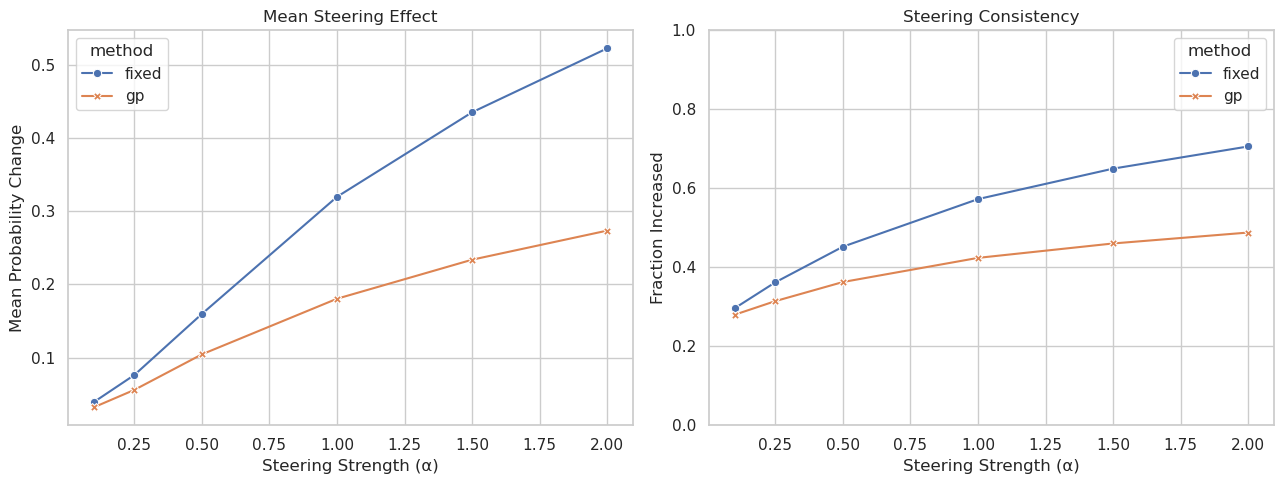

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(
    data=results_df,
    x="alpha",
    y="mean_change",
    hue="method",
    style="method",
    markers=True,
    dashes=False,
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Mean Steering Effect")
axes[0].set_xlabel("Steering Distance")
axes[0].set_ylabel("Mean Probability Change")

sns.lineplot(
    data=results_df,
    x="alpha",
    y="fraction_increased",
    hue="method",
    style="method",
    markers=True,
    dashes=False,
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Steering Consistency")
axes[1].set_xlabel("Steering Distance")
axes[1].set_ylabel("Fraction Increased")
axes[1].set_ylim(0, 1)
axes[0].set_xlabel("Steering Strength (α)")
axes[1].set_xlabel("Steering Strength (α)")
plt.tight_layout()
plt.show()

In [63]:
import joblib
import numpy as np
import pandas as pd

probe = joblib.load(
    "../Probes/llama13b-probes/best_nonlinear_probe.pkl"
)

N_EVAL = 1000
ALPHAS = [0.1, 0.25, 0.5, 1.0, 1.5, 2.0]
STEP = 0.5

cols = {x: i for i, x in enumerate(mlb.classes_)}
Ztr = best_scaler.transform(best_pca.transform(Xtr_small))
results = []


def gp_grad_batch(gp, Z, delta=0.01, beta=0.5):
    d = Z.shape[1]
    eye = np.eye(d) * delta

    plus = (Z[:, None, :] + eye).reshape(-1, d)
    minus = (Z[:, None, :] - eye).reshape(-1, d)

    mp, sp = gp.predict(plus, return_std=True)
    mm, sm = gp.predict(minus, return_std=True)

    return (
        (mp - beta * sp) - (mm - beta * sm)
    ).reshape(len(Z), d) / (2 * delta)


def steer_gp_batch(gp, Z, distance):
    Z = Z.copy()
    moved = 0.0

    while moved < distance:
        grad = gp_grad_batch(gp, Z, beta=BETA)

        norms = np.linalg.norm(grad, axis=1, keepdims=True)
        grad = grad / np.maximum(norms, 1e-12)

        step = min(STEP, distance - moved)
        Z += step * grad
        moved += step

    return Z


for label, gp in best_gps.items():
    print("Starting", label)

    col = cols[label]

    X = Xte_small[Yte_small[:, col] == 0][:N_EVAL]

    if len(X) == 0:
        continue

    Z = best_scaler.transform(best_pca.transform(X))
    before = probe.predict_proba(X)[:, col]

    direction = (
        Ztr[Ytr_small[:, col] == 1].mean(axis=0)
        - Ztr[Ytr_small[:, col] == 0].mean(axis=0)
    )

    norm = np.linalg.norm(direction)

    if norm < 1e-12:
        print("Skipping zero direction:", label)
        continue

    direction /= norm

    for alpha in ALPHAS:
        Z_fixed = Z + alpha * direction
        Z_gp = steer_gp_batch(gp, Z, alpha)

        for method, Znew in [
            ("fixed", Z_fixed),
            ("gp", Z_gp),
        ]:
            Xnew = best_pca.inverse_transform(
                best_scaler.inverse_transform(Znew)
            )

            after = probe.predict_proba(Xnew)[:, col]
            change = after - before

            results.append({
                "label": label,
                "method": method,
                "alpha": alpha,
                "mean_change": change.mean(),
                "fraction_increased": (change > 0).mean(),
            })

results_df = pd.DataFrame(results)

print(results_df)

Starting 1
Starting 2
Starting 3
Starting 4
Starting 5
Starting 7
    label method  alpha  mean_change  fraction_increased
0       1  fixed   0.10    -0.002059               0.631
1       1     gp   0.10    -0.002059               0.602
2       1  fixed   0.25    -0.001901               0.685
3       1     gp   0.25    -0.001898               0.608
4       1  fixed   0.50    -0.001532               0.759
..    ...    ...    ...          ...                 ...
67      7     gp   1.00    -0.000848               0.597
68      7  fixed   1.50    -0.000796               0.827
69      7     gp   1.50    -0.000822               0.612
70      7  fixed   2.00    -0.000753               0.843
71      7     gp   2.00    -0.000776               0.626

[72 rows x 5 columns]


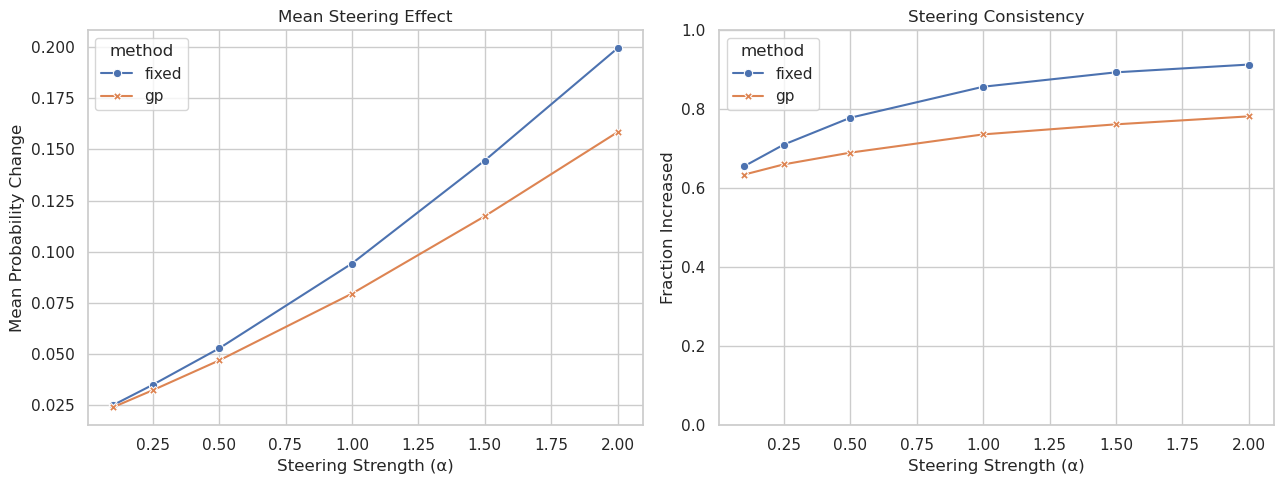

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(
    data=results_df,
    x="alpha",
    y="mean_change",
    hue="method",
    style="method",
    markers=True,
    dashes=False,
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Mean Steering Effect")
axes[0].set_xlabel("Steering Distance")
axes[0].set_ylabel("Mean Probability Change")

sns.lineplot(
    data=results_df,
    x="alpha",
    y="fraction_increased",
    hue="method",
    style="method",
    markers=True,
    dashes=False,
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Steering Consistency")
axes[1].set_xlabel("Steering Distance")
axes[1].set_ylabel("Fraction Increased")
axes[1].set_ylim(0, 1)
axes[0].set_xlabel("Steering Strength (α)")
axes[1].set_xlabel("Steering Strength (α)")
plt.tight_layout()
plt.show()

In [65]:
results = []

for label, gp in best_gps.items():
    print("Starting", label)
    col = cols[label]

    X = Xte_small[Yte_small[:, col] == 0][:N_EVAL]
    if len(X) == 0:
        continue

    Z = best_scaler.transform(best_pca.transform(X))
    before_all = probe.predict_proba(X)

    direction = (
        Ztr[Ytr_small[:, col] == 1].mean(0)
        - Ztr[Ytr_small[:, col] == 0].mean(0)
    )
    direction /= np.maximum(np.linalg.norm(direction), 1e-12)

    other_cols = [i for i in range(before_all.shape[1]) if i != col]

    for alpha in ALPHAS:
        steered = {
            "fixed": Z + alpha * direction,
            "gp": steer_gp_batch(gp, Z, alpha),
        }

        for method, Znew in steered.items():
            Xnew = best_pca.inverse_transform(
                best_scaler.inverse_transform(Znew)
            )

            after_all = probe.predict_proba(Xnew)

            target_change = (
                after_all[:, col] - before_all[:, col]
            )

            collateral_change = np.abs(
                after_all[:, other_cols]
                - before_all[:, other_cols]
            ).mean(axis=1)

            results.append({
                "label": label,
                "method": method,
                "alpha": alpha,
                "target_change": target_change.mean(),
                "collateral_change": collateral_change.mean(),
                "fraction_increased": (target_change > 0).mean(),
            })

results_df = pd.DataFrame(results)
print(results_df)

Starting 1
Starting 2
Starting 3
Starting 4
Starting 5
Starting 7
    label method  alpha  target_change  collateral_change  fraction_increased
0       1  fixed   0.10      -0.002059           0.065583               0.631
1       1     gp   0.10      -0.002059           0.065466               0.602
2       1  fixed   0.25      -0.001901           0.065814               0.685
3       1     gp   0.25      -0.001898           0.065514               0.608
4       1  fixed   0.50      -0.001532           0.066436               0.759
..    ...    ...    ...            ...                ...                 ...
67      7     gp   1.00      -0.000848           0.071611               0.597
68      7  fixed   1.50      -0.000796           0.073430               0.827
69      7     gp   1.50      -0.000822           0.074413               0.612
70      7  fixed   2.00      -0.000753           0.077207               0.843
71      7     gp   2.00      -0.000776           0.077608               0.62

In [67]:
matched = []

for label in results_df["label"].unique():
    gp_rows = results_df[
        (results_df["label"] == label)
        & (results_df["method"] == "gp")
    ]

    fixed_rows = results_df[
        (results_df["label"] == label)
        & (results_df["method"] == "fixed")
    ]

    for _, gp_row in gp_rows.iterrows():
        difference = np.abs(
            fixed_rows["target_change"]
            - gp_row["target_change"]
        )

        fixed_row = fixed_rows.loc[difference.idxmin()]

        matched.append({
            "label": label,
            "gp_alpha": gp_row["alpha"],
            "fixed_alpha": fixed_row["alpha"],
            "gp_target_change": gp_row["target_change"],
            "fixed_target_change": fixed_row["target_change"],
            "gp_collateral": gp_row["collateral_change"],
            "fixed_collateral": fixed_row["collateral_change"],
            "gp_minus_fixed_collateral":
                gp_row["collateral_change"]
                - fixed_row["collateral_change"],
        })

matched_df = pd.DataFrame(matched)

# Keep only reasonably close target effects
matched_df = matched_df[
    np.abs(
        matched_df["gp_target_change"]
        - matched_df["fixed_target_change"]
    ) < 0.02
]

print(matched_df)

    label  gp_alpha  fixed_alpha  gp_target_change  fixed_target_change  \
0       1      0.10         0.10     -2.059261e-03            -0.002059   
1       1      0.25         0.25     -1.898163e-03            -0.001901   
2       1      0.50         0.50     -1.519964e-03            -0.001532   
3       1      1.00         1.00     -1.825749e-04            -0.000337   
4       1      1.50         1.50      2.120644e-03             0.001982   
5       1      2.00         2.00      5.161851e-03             0.006184   
6       2      0.10         0.10      5.489811e-02             0.057610   
7       2      0.25         0.25      7.228409e-02             0.078586   
8       2      0.50         0.50      1.015074e-01             0.112798   
9       2      1.00         1.00      1.624859e-01             0.180690   
12      3      0.10         0.10      1.754084e-02             0.019109   
13      3      0.25         0.25      2.792677e-02             0.032939   
14      3      0.50      

In [69]:
matched_df

,label,gp_alpha,fixed_alpha,gp_target_change,fixed_target_change,gp_collateral,fixed_collateral,gp_minus_fixed_collateral
0,1,0.10,0.10,-2.059261e-03,-0.002059,0.065466,0.065583,-0.000117
1,1,0.25,0.25,-1.898163e-03,-0.001901,0.065514,0.065814,-0.000300
2,1,0.50,0.50,-1.519964e-03,-0.001532,0.065824,0.066436,-0.000612
3,1,1.00,1.00,-1.825749e-04,-0.000337,0.067620,0.068931,-0.001311
4,1,1.50,1.50,2.120644e-03,0.001982,0.070653,0.073775,-0.003122
5,1,2.00,2.00,5.161851e-03,0.006184,0.074491,0.081316,-0.006825
6,2,0.10,0.10,5.489811e-02,0.057610,0.054428,0.054450,-0.000022
7,2,0.25,0.25,7.228409e-02,0.078586,0.055223,0.055317,-0.000095
8,2,0.50,0.50,1.015074e-01,0.112798,0.057036,0.057456,-0.000420
9,2,1.00,1.00,1.624859e-01,0.180690,0.063056,0.064187,-0.001132


In [5]:
def make_gp_delta(z0, direction, alpha):
    z_new = z0 + alpha * direction

    z0_pca = best_scaler.inverse_transform(z0[None])
    z_new_pca = best_scaler.inverse_transform(z_new[None])

    x0 = best_pca.inverse_transform(z0_pca)[0]
    x_new = best_pca.inverse_transform(z_new_pca)[0]

    return x_new - x0
def find_gp_direction(
    z0, gp, n=1000, beta=0.5,
    radius=1.0, seed=42
):
    rng = np.random.default_rng(seed)

    dirs = rng.normal(size=(n, z0.size))
    dirs /= np.maximum(
        np.linalg.norm(dirs, axis=1, keepdims=True),
        1e-12
    )

    candidates = z0[None, :] + radius * dirs
    means, stds = gp.predict(candidates, return_std=True)

    scores = means - beta * stds
    return dirs[np.argmax(scores)]
def make_steering_hook(delta_activation):
    delta = torch.as_tensor(
        delta_activation,
        dtype=model.dtype,
        device=model.device
    )

    def hook(module, inputs, output):
        if isinstance(output, tuple):
            hidden = output[0].clone()
            hidden[:, -1, :] += delta
            return (hidden,) + output[1:]

        hidden = output.clone()
        hidden[:, -1, :] += delta
        return hidden

    return hook

In [10]:
LABELS = [1, 2, 3, 4, 5, 7]
N_EVAL = 1000
N_DIRS = 1000
ALPHA = 3.0
BETA = 0.5
SEED = 42

class_to_col = {x: i for i, x in enumerate(mlb.classes_)}
X_test = np.asarray(test_cache[REP_LAYER])
Y_test_arr = np.asarray(Y_test)
x0 = X_test[i]
z0 = best_scaler.transform(best_pca.transform(x0[None]))[0]
methods = {
    "gp_mean": make_gp_delta(
        z0,
        find_gp_direction(z0, gp, beta=0.0),
        alpha
    ),

    "gp_uncertainty": make_gp_delta(
        z0,
        find_gp_direction(z0, gp, beta=BETA),
        alpha
    ),

    "fixed": make_gp_delta(
        z0,
        fixed_direction,
        alpha
    ),}


NameError: name 'test_cache' is not defined

In [ ]:
import numpy as np
import pandas as pd



def get_dirs(z0, gp, seed):
    rng = np.random.default_rng(seed)
    dirs = rng.normal(size=(N_DIRS, z0.size))
    dirs /= np.maximum(np.linalg.norm(dirs, axis=1, keepdims=True), 1e-12)
    means, stds = gp.predict(z0[None] + dirs, return_std=True)
    return dirs[np.argmax(means)], dirs[np.argmax(means - BETA * stds)]

rows = []

for label in LABELS:
    print("Starting", label)
    gp = best_gps[label]
    col = class_to_col[label]
    indices = np.where(Y_test_arr[:, col] == 0)[0][:N_EVAL]

    for i in indices:
        x0 = X_test[i]
        z0 = best_scaler.transform(best_pca.transform(x0[None]))[0]
        mean_dir, unc_dir = get_dirs(z0, gp, SEED + int(i))
        mean0, std0 = gp.predict(z0[None], return_std=True)

        for method, direction in {
            "gp_mean": mean_dir,
            "gp_uncertainty": unc_dir,
        }.items():
            z1 = z0 + ALPHA * direction
            mean1, std1 = gp.predict(z1[None], return_std=True)

            rows.append({
                "label": label,
                "sample": i,
                "method": method,
                "mean_change": float(mean1[0] - mean0[0]),
                "uncertainty_change": float(std1[0] - std0[0]),
            })

results_df = pd.DataFrame(rows)

summary_df = (
    results_df
    .groupby(["label", "method"])[["mean_change", "uncertainty_change"]]
    .mean()
    .reset_index()
)

print(summary_df)